<a href="https://colab.research.google.com/github/fleqi/proyecto-mineria/blob/colab/hito1/notebooks/datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
!git clone https://github.com/fleqi/proyecto-mineria

fatal: destination path 'proyecto-mineria' already exists and is not an empty directory.


# EDA Hito 1

---



In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
DATA = Path("/content/proyecto-mineria/hito1/data")

---

## CONAF



Para empezar el análisis exploratorio, podemos fijarnos en los datos de la CONAF, que si bien son poco específicos, al tener los datos agregados por temporada permiten entender mejor las estadísticas.

In [113]:
CONAF = DATA / "conaf"

In [114]:
f1 = CONAF / "1.- Ocurrencia y Daño Histórico Nacional, 1985 - 2024_octubre.xls"
df1 = pd.read_excel(f1, sheet_name="Historico", header=7)
df1 = df1.iloc[2:, 2:7]
df1 = df1.dropna()
df1.columns = "Año", "denominacion", "n_incendios", "superficie_ha", "superficie_prom_ha"
df1["Año"] = df1["Año"].str.slice(0, 4).astype(int)
df1.head()

,Año,denominacion,n_incendios,superficie_ha,superficie_prom_ha
2,1963,64.0,435.0,19600.0,45.057471
3,1964,65.0,269.0,17200.0,63.940520
4,1965,66.0,396.0,19900.0,50.252525
5,1966,67.0,307.0,15820.0,51.530945
6,1967,68.0,507.0,61314.0,120.934911


In [115]:
df1.describe()

,Año,denominacion,n_incendios,superficie_ha,superficie_prom_ha
count,61.000000,61.000000,61.000000,61.000000,61.000000
mean,1993.000000,53.016393,4641.262295,65912.350987,19.801051
std,17.752934,35.695701,2257.375740,86948.685625,23.609790
min,1963.000000,0.000000,269.000000,9604.000000,2.031436
25%,1978.000000,15.000000,3380.000000,25545.000000,7.569701
50%,1993.000000,69.000000,5252.000000,43592.000000,11.090759
75%,2008.000000,84.000000,6214.000000,80064.190000,16.789704
max,2023.000000,99.000000,8127.000000,570197.394200,120.934911


#### Gráfico de número de incendios por año

<Axes: title={'center': 'Cantidad de incendios por año en Chile'}, xlabel='Año', ylabel='Cantidad de incendios'>

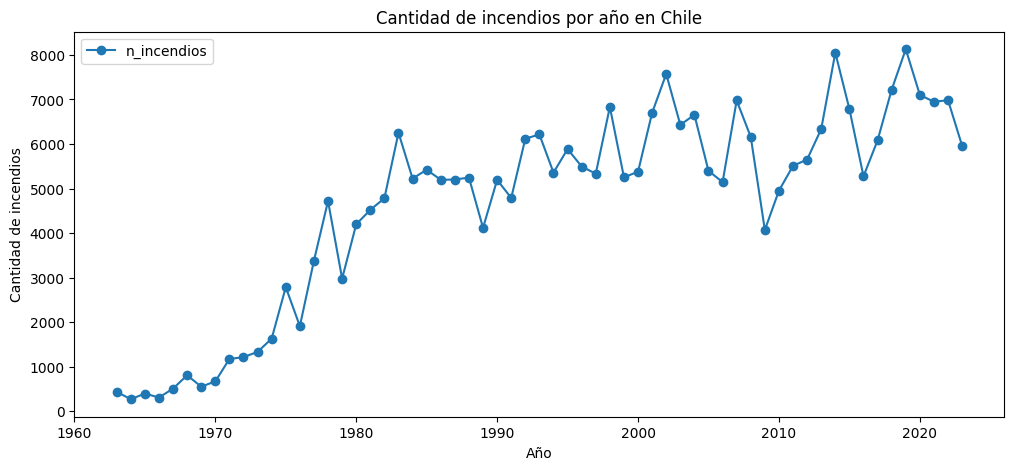

In [116]:
df1.plot.line(x = 'Año', y = 'n_incendios', marker = 'o', figsize = (12,5), title = "Cantidad de incendios por año en Chile", ylabel = "Cantidad de incendios")

Con este gráfico podemos plantearnos si los últimos años de cambio climático tienen influencia sobre la cantidad de incendios anuales.

#### Gráfico de superficie promedio quemada en hectáreas por año

<Axes: title={'center': 'Superficie quemada media al año en Chile'}, xlabel='Año', ylabel='Superficie quemada media (ha)'>

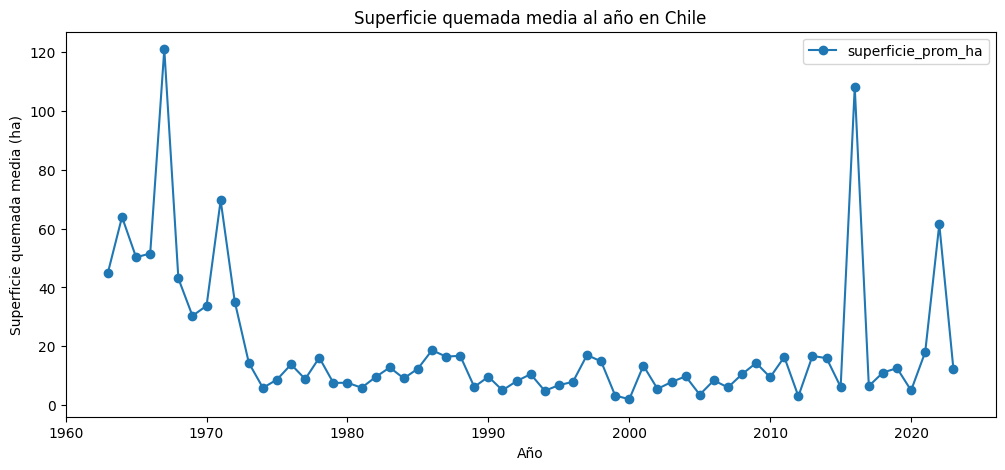

In [117]:
df1.plot.line(x = 'Año', y = 'superficie_prom_ha', marker = 'o', figsize = (12,5), title = "Superficie quemada media al año en Chile", ylabel = "Superficie quemada media (ha)")

Se nota una clara bajada en la superficie quemada con los años, que se podría atribuir a mejores tecnologías para combatir incendios, sin embargo, en los últimos años se ha evidenciado una subida que se podría atribuir a múltiples causas como la cantidad de incendios contra la capacidad de respuesta o las condiciones climáticas y la influencia que tienen sobre la proliferación de estos.

Queda en duda si es que estos daños podrían reducirse teniendo conocimiento de las condiciones climáticas.

---


## DMC
El DMC tiene datos meteorológicos de muchas partes, por lo que podemos usarlo para evaluar las temperaturas por cada año.

Para esto ignoraremos los datos de fuera del continente, ya que podrían inducir variaciones no deseadas y no son el foco del análisis.

### Temperatura

In [118]:
DMC = DATA / "dmc"
TEMP = DMC / "temperatura"

In [119]:
archivos = sorted((TEMP).glob("*.csv"))
temp = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
temp=temp[~temp["CodigoNacional"].isin([270001.0, 330031.0, 950001.0])]
temp = temp.dropna()
temp = temp.drop_duplicates()
temp["Año"] = temp["date"].dt.year
temp.head()

,date,CodigoNacional,nombreEstacion,latitud,longitud,temp_mean,Año
0,2000-01-01,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,21.978261,2000
1,2000-01-01,200006.0,Diego Aracena Iquique Ap.,-20.54917,-70.18111,20.769565,2000
2,2000-01-01,220002.0,"El Loa, Calama Ad.",-22.49806,-68.89250,18.826667,2000
4,2000-01-01,290004.0,"La Florida, La Serena Ad.",-29.91444,-71.20667,17.164706,2000
5,2000-01-01,330007.0,"Rodelillo, Ad.",-33.06528,-71.55639,16.083333,2000


<Axes: title={'center': 'Temperatura media anual en Chile'}, xlabel='Año', ylabel='Temperatura media (°C)'>

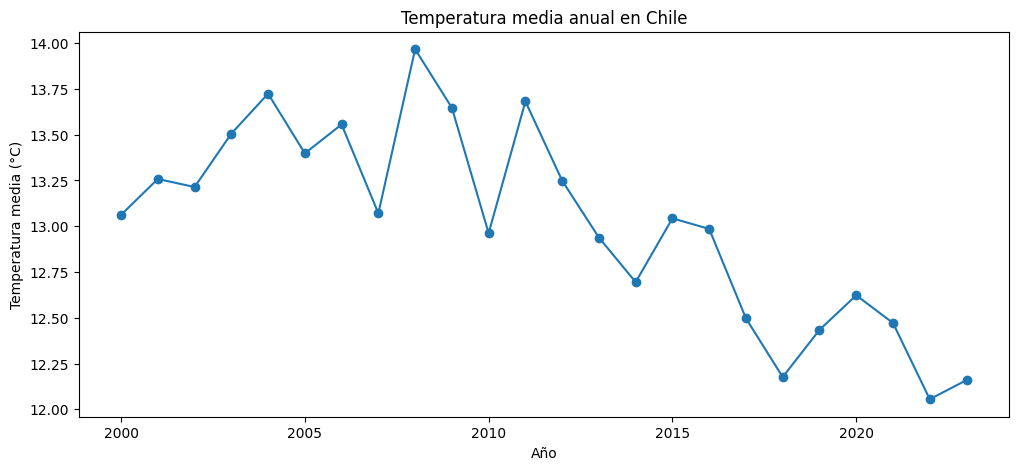

In [120]:
temp2 = temp.groupby(["Año"])["temp_mean"].mean()
temp2.plot.line(x = 'Año', y = 'temp_mean', marker = 'o', figsize = (12,5), ylabel = "Temperatura media (°C)", title = "Temperatura media anual en Chile")

Como se ve en el gráfico, la temperatura promedio en Chile ha variado mucho a partir de los 2000, y parece ir en bajada a partir de el 2007, sin embargo, por lo largo del país, no podemos concluir nada aún.
Podemos hacer un análisis por regiones.

Para hacer esto más fácil, podemos basarnos en la latitud, definiendo:
- Norte: lat > -32°
- Centro: -38° < lat < -32°
- Sur: lat < -38°

In [121]:
temp["Zona"] = pd.cut(temp["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
temp.head()

,date,CodigoNacional,nombreEstacion,latitud,longitud,temp_mean,Año,Zona
0,2000-01-01,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,21.978261,2000,Norte
1,2000-01-01,200006.0,Diego Aracena Iquique Ap.,-20.54917,-70.18111,20.769565,2000,Norte
2,2000-01-01,220002.0,"El Loa, Calama Ad.",-22.49806,-68.89250,18.826667,2000,Norte
4,2000-01-01,290004.0,"La Florida, La Serena Ad.",-29.91444,-71.20667,17.164706,2000,Norte
5,2000-01-01,330007.0,"Rodelillo, Ad.",-33.06528,-71.55639,16.083333,2000,Centro


/tmp/ipykernel_632/1609510223.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_zonas = temp.groupby(["Año", "Zona"])["temp_mean"].mean().unstack()


<Axes: title={'center': 'Temperatura media anual por zona'}, xlabel='Año', ylabel='Temperatura media (°C)'>

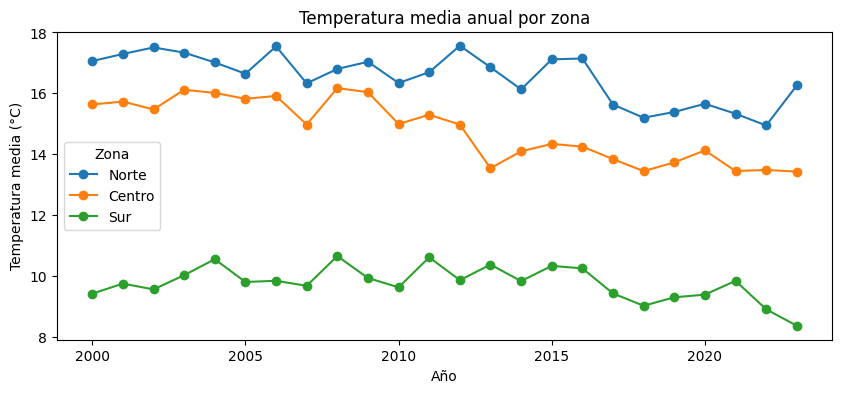

In [122]:
temp_zonas = temp.groupby(["Año", "Zona"])["temp_mean"].mean().unstack()
temp_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Temperatura media (°C)",
    title = "Temperatura media anual por zona"
)

### Humedad

In [135]:
HUM = DMC / "humedad"
archivos = sorted((HUM).glob("*.csv"))
hum = pd.concat((pd.read_csv(f, parse_dates=["date"]) for f in archivos), ignore_index=True)
hum=hum[~hum["CodigoNacional"].isin([270001.0, 330031.0, 950001.0])]
hum = hum.dropna()
hum = hum.drop_duplicates()
hum["Año"] = hum["date"].dt.year
hum.head()

,date,CodigoNacional,nombreEstacion,latitud,longitud,humedad_mean,Año
0,2000-01-01,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,72.347826,2000
1,2000-01-01,200006.0,Diego Aracena Iquique Ap.,-20.54917,-70.18111,64.565217,2000
2,2000-01-01,220002.0,"El Loa, Calama Ad.",-22.49806,-68.89250,35.933333,2000
4,2000-01-01,290004.0,"La Florida, La Serena Ad.",-29.91444,-71.20667,76.411765,2000
5,2000-01-01,330007.0,"Rodelillo, Ad.",-33.06528,-71.55639,70.250000,2000


<Axes: title={'center': 'Humedad media anual en Chile'}, xlabel='Año', ylabel='Humedad relativa (%)'>

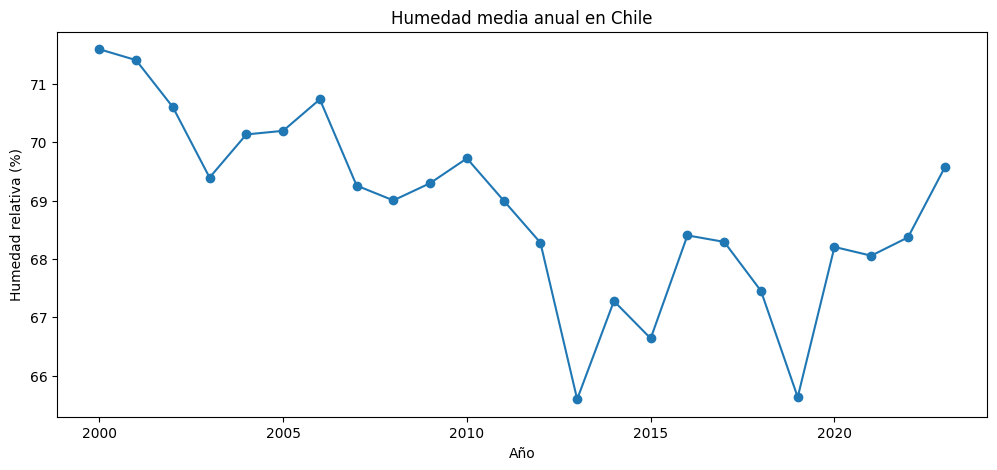

In [136]:
hum2 = hum.groupby(["Año"])["humedad_mean"].mean()
hum2.plot.line(x = 'Año', y = 'humedad_mean', marker = 'o', figsize = (12,5), title = "Humedad media anual en Chile", ylabel = "Humedad relativa (%)")

In [137]:
hum["Zona"] = pd.cut(hum["latitud"], bins=[-90, -38, -32, 0], labels=["Sur", "Centro", "Norte"])
hum.head()

,date,CodigoNacional,nombreEstacion,latitud,longitud,humedad_mean,Año,Zona
0,2000-01-01,180005.0,"Chacalluta, Arica Ap.",-18.35555,-70.34028,72.347826,2000,Norte
1,2000-01-01,200006.0,Diego Aracena Iquique Ap.,-20.54917,-70.18111,64.565217,2000,Norte
2,2000-01-01,220002.0,"El Loa, Calama Ad.",-22.49806,-68.89250,35.933333,2000,Norte
4,2000-01-01,290004.0,"La Florida, La Serena Ad.",-29.91444,-71.20667,76.411765,2000,Norte
5,2000-01-01,330007.0,"Rodelillo, Ad.",-33.06528,-71.55639,70.250000,2000,Centro


/tmp/ipykernel_632/3473625353.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hum_zonas = hum.groupby(["Año", "Zona"])["humedad_mean"].mean().unstack()


<Axes: title={'center': 'Humedad media anual por zona'}, xlabel='Año', ylabel='Humedad relativa (%)'>

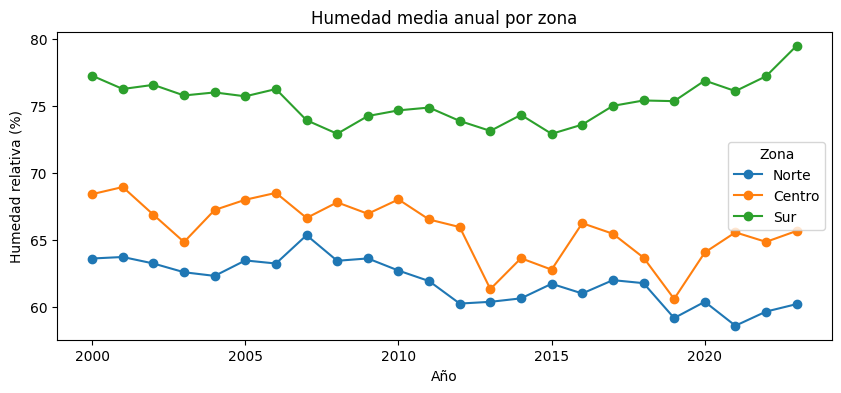

In [138]:
hum_zonas = hum.groupby(["Año", "Zona"])["humedad_mean"].mean().unstack()
hum_zonas[["Norte", "Centro", "Sur"]].plot(
    marker = "o",
    figsize = (10, 4),
    ylabel = "Humedad relativa (%)",
    title = "Humedad media anual por zona"
)